# Proyecto 1: clasificación de sentimiento de reseñas (modelo final)

**Pedro Pablo Sanín Trujillo, 202221527**

## Problema

Dada una reseña de un producto escrita en español, hay que predecir si la opinión global del cliente es `negativo`, `neutral` o `positivo`. La métrica de la competencia es la **accuracy**. Las reglas de la Parte 1 solo permiten modelos clásicos de `scikit-learn` con representaciones como bolsa de palabras, TF-IDF y n-gramas; no se pueden usar redes neuronales ni embeddings preentrenados.

La dificultad principal, como dice el enunciado, es que muchas reseñas tienen **elogios y quejas a la vez** ("la batería es excelente, pero la cámara resultó decepcionante"). El sentimiento global depende del **orden** de las opiniones, de la **negación** y de los **conectores de contraste**, y eso es justamente lo que una bolsa de palabras pierde. Casi todas las decisiones de este notebook buscan devolverle al modelo esa información sin salir de las representaciones clásicas.

## Resumen del modelo final

El modelo final es un `StackingClassifier` que combina dos modelos con preprocesamientos distintos:

1. Un **voting classifier** (voto suave) con los cuatro mejores modelos lineales del grid search. Cada uno usa n-gramas del texto completo, de la última oración y de la oración que sigue al último conector de contraste.
2. Un **modelo de opiniones**: una regresión logística sobre las opiniones de la reseña, marcadas con su posición (última o anterior) y con el conector que las introduce.

Una regresión logística final aprende a combinar las probabilidades de ambos.

| Modelo (partición train/test 80/20) | Accuracy en test |
|---|---|
| Mejores modelos individuales del grid search | ≈ 0.89 |
| Voting classifier | 0.8979 |
| Modelo de opiniones | 0.8892 |
| **Stacking (modelo final)** | **0.9038** |

## Estructura

1. Librerías
2. Carga y exploración de los datos
3. Preprocesamiento del texto: normalización, stopwords, negación y stemming
4. Representación del texto: rasgos según la posición
5. Partición train/test y comparación de representaciones
6. Comparación inicial de modelos
7. Ajuste de hiperparámetros con `GridSearchCV`
8. Voting classifier
9. Análisis de errores
10. Segundo modelo (opiniones etiquetadas) y stacking
11. Resultados del modelo final
12. Archivo de submission
13. Conclusiones y limitaciones

## 1. Librerías

- **NLTK**: `word_tokenize` para tokenizar (necesita el recurso `punkt_tab`), la lista de `stopwords` en español y `SnowballStemmer("spanish")` para el stemming.
- **scikit-learn**: vectorizadores (`CountVectorizer` y `TfidfVectorizer`), `ColumnTransformer` y `FunctionTransformer` para armar el preprocesamiento como pipeline, los clasificadores, la validación cruzada y las métricas.
- **imbalanced-learn**: usamos su `Pipeline`, que funciona igual que el de scikit-learn y además admitiría pasos de remuestreo. Como veremos en la sección 2, las clases están casi balanceadas, así que no remuestreamos.

In [116]:
# Importación de librerías
import nltk
import numpy as np
import pandas as pd
from imblearn.pipeline import Pipeline
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
from nltk.tokenize import word_tokenize
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import (
    train_test_split,
    KFold,
    GridSearchCV,
    cross_val_score,
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    f1_score,
)
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.utils import resample
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB, GaussianNB

nltk.download(
    "punkt_tab"
)  # Descargamos el tokenizador de NLTK para poder usar word_tokenize
nltk.download(
    "stopwords"
)  # Descargamos las stopwords de NLTK para poder filtrar palabras comunes

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/pedropablosanintrujillo/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/pedropablosanintrujillo/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## 2. Carga y exploración de los datos

`data/train.csv` tiene 12 000 reseñas etiquetadas con las columnas `id`, `text` y `label`. Trabajamos sobre una copia para no modificar el DataFrame original.

In [117]:
df = pd.read_csv("data/train.csv")

data = df.copy(deep=True)

print(f"Documentos cargados: {len(data)}")
data.head()

Documentos cargados: 12000


,id,text,label
0,0,Lo pedí un martes por la noche y me llegó al d...,neutral
1,1,Se lo compré a un familiar después de pensarla...,positivo
2,2,Lo pedí a mediados de mes y me llegó en tres d...,negativo
3,3,Compré esto en línea y llegó en unos tres días...,negativo
4,4,Compré este kit el mes pasado porque necesitab...,positivo


In [118]:
data.describe(include=["object"])

/var/folders/bl/m8gd2pc14237m1mz5n7dg_nw0000gn/T/ipykernel_38960/2389127942.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  data.describe(include=["object"])


,text,label
count,12000,12000
unique,12000,3
top,Lo pedí un martes por la noche y me llegó al d...,positivo
freq,1,4212


In [119]:
data["label"].value_counts()

label
positivo    4212
negativo    4212
neutral     3576
Name: count, dtype: int64

**Observaciones.**

- No hay valores faltantes y los 12 000 textos son únicos, así que no hay duplicados que puedan filtrar información entre train y test.
- Las clases están casi balanceadas: 35.1 % positivo, 35.1 % negativo y 29.8 % neutral. Por eso:
  - no hace falta remuestrear ni ponderar las clases;
  - la accuracy (la métrica de la competencia) es una métrica razonable, porque no la domina una clase mayoritaria;
  - de todos modos, la partición train/test y los folds de validación cruzada se **estratifican** para conservar estas proporciones.

## 3. Preprocesamiento del texto

Primero definimos cómo se convierte una reseña en una lista de tokens. Cada decisión responde a algo que vimos en los datos.

### 3.1 Normalización y stopwords

- **Quitamos tildes y diéresis** (`quitar_tildes`). Muchas reseñas están escritas sin tildes ("llego", "asi"), y sin este paso "llegó" y "llego" serían tokens distintos que dividen la misma información.
- **Eliminamos stopwords**, pero no todas. La lista de NLTK incluye palabras que cambian el sentido de la frase y que conservamos:
  - negadores: "no", "nunca", "ni", "nadie", "nada"...;
  - el conector de contraste "pero" y la preposición "sin";
  - intensificadores: "muy", "más", "mucho", "poco".

  Quitarlas haría que "no me gustó" y "me gustó" produjeran los mismos tokens.
- Las stopwords se comparan **sin tildes**, igual que el texto normalizado.
- `stopwords_minimas` es una lista alternativa más corta (artículos, preposiciones y pronombres) que no rompe frases hechas como "con los ojos cerrados". El modelo final no la usa; se deja definida para probar el preprocesador con ella.

In [120]:
import unicodedata


def quitar_tildes(text):
    """Elimina tildes y diéresis, pues muchas reseñas están escritas sin ellas."""
    return unicodedata.normalize("NFKD", text).encode("ascii", "ignore").decode("ascii")


# Lista de stopwords en español de NLTK (313 palabras)
spanish_stopwords_completas = set(stopwords.words("spanish"))

# Palabras que NLTK considera stopwords pero que cambian el sentido de la frase: negadores,
# conectores de contraste ("pero", "sin") e intensificadores ("muy", "mucho", "nada"). Se conservan.

palabras_negativas = {
    "no",
    "nunca",
    "jamás",
    "nadie",
    "ninguno",
    "poco",
    "ni",
    "pero",
    "sin",
    "muy",
    "más",
    "mucho",
    "nada",
    "contra",
    "algo",
}

# Se comparan sin tildes porque el texto también se normaliza sin tildes
spanish_stopwords = {
    quitar_tildes(w) for w in spanish_stopwords_completas - palabras_negativas
}

# Lista mínima (artículos, preposiciones y pronombres) para no romper frases hechas como "con los ojos cerrados".
# El modelo final no la usa (usa spanish_stopwords); se deja para probar el preprocesador con ella.
stopwords_minimas = {
    quitar_tildes(w)
    for w in [
        "el",
        "la",
        "los",
        "las",
        "un",
        "una",
        "unos",
        "unas",
        "de",
        "del",
        "al",
        "y",
        "o",
        "e",
        "a",
        "en",
        "que",
        "lo",
        "le",
        "les",
        "se",
        "me",
        "mi",
        "mis",
        "su",
        "sus",
    ]
}

print(f"Cantidad de stopwords en español: {len(spanish_stopwords)}")
print(f"Contiene no: {'no' in spanish_stopwords}")
print(spanish_stopwords)

Cantidad de stopwords en español: 295
Contiene no: False
{'sois', 'hubiesen', 'habras', 'estada', 'sintiendo', 'un', 'fuera', 'tuviese', 'tu', 'fueramos', 'por', 'hay', 'estuvieses', 'has', 'e', 'tambien', 'ya', 'ha', 'estos', 'hayas', 'tuvieras', 'vosotros', 'sentidas', 'tanto', 'tendriamos', 'estareis', 'otros', 'habeis', 'al', 'teniendo', 'habrian', 'estamos', 'del', 'la', 'hubieras', 'tuvisteis', 'hubo', 'nuestras', 'entre', 'fuese', 'estar', 'seras', 'hayais', 'tuviste', 'sereis', 'tuvimos', 'tuya', 'tenias', 'soy', 'estan', 'tenidas', 'habremos', 'fueras', 'estuvieran', 'una', 'hubieses', 'mia', 'lo', 'fuiste', 'tendrias', 'te', 'le', 'seamos', 'tengas', 'nos', 'estuvieseis', 'sobre', 'esteis', 'eso', 'estuviste', 'han', 'tendran', 'tuve', 'sentid', 'o', 'tiene', 'fuesemos', 'sere', 'hubieran', 'estemos', 'serias', 'y', 'estariamos', 'habriais', 'nosotros', 'estabamos', 'algunos', 'tuviera', 'tendria', 'que', 'mis', 'algunas', 'tendremos', 'esas', 'seria', 'mias', 'las', 'estuvis

### 3.2 Tokenización, marcado de negación y stemming

`tokenizer_stemmer` hace todo el preprocesamiento de una reseña y es el tokenizador que reciben los vectorizadores:

1. **Minúsculas y sin tildes.**
2. **Tokenización** con `word_tokenize` de NLTK, que separa también los signos de puntuación.
3. **Marcado de negación** (`marcar_negacion`). Una bolsa de palabras no sabe si una palabra está negada, así que a cada palabra que sigue a un negador ("no", "nunca", "sin", "nada"...) le agregamos el prefijo `NEG_`, hasta el siguiente signo de puntuación o conector adversativo ("pero", "aunque", "sino"). Así, "no me gustó" produce `NEG_gust`, un rasgo distinto de `gust`. Este paso va **antes** de quitar la puntuación, porque los signos cierran el alcance de la negación.
4. **Filtrado**: se descartan la puntuación, los números y las stopwords.
5. **Stemming** con `SnowballStemmer("spanish")`: "compra", "compras" y "compramos" se reducen a la misma raíz. En este problema las terminaciones casi no aportan información y el stemming reduce el vocabulario, lo que también reduce la varianza de los modelos.

In [121]:
stemmer = SnowballStemmer("spanish")

# Palabras que niegan lo que viene después de ellas (sin tildes, como el texto normalizado)
NEGADORES = {
    "no",
    "nunca",
    "jamas",
    "ni",
    "nada",
    "sin",
    "tampoco",
    "nadie",
    "ninguno",
    "ninguna",
}

# Tokens que cierran el alcance de la negación: puntuación y conectores adversativos.
# Así, en "no me gustó, pero la pantalla es buena" la negación no llega a "buena".
FIN_NEGACION = {".", ",", ";", ":", "!", "?", "pero", "aunque", "sino"}
# Prefijo que distingue una palabra negada de la misma palabra sin negar (gust vs. NEG_gust)
NEG_PREFIX = "NEG_"


def marcar_negacion(tokens):
    """Agrega el prefijo NEG_ a las palabras dentro del alcance de una negación, es decir,
    desde el negador hasta el siguiente signo de puntuación o conector adversativo."""
    marcados, negando = [], False
    for t in tokens:
        if t in FIN_NEGACION:
            negando = False
        elif t in NEGADORES:
            negando = True
        elif negando:
            t = NEG_PREFIX + t
        marcados.append(t)
    return marcados


def tokenizer_stemmer(text, stopwords=spanish_stopwords, stemming=True):
    """Hacemos el preprocesamiento del texto: normalización, tokenización, marcado de negación y stemming en una sola función para luego pasarlo al pipeline de procesamiento.

    stopwords: conjunto de palabras a eliminar (sin tildes).
    stemming: si es True, cada palabra se reduce a su raíz con SnowballStemmer.
    """
    # Minúsculas y sin tildes -> tokens de NLTK -> prefijo NEG_ dentro del alcance de cada negación.
    # La negación se marca antes de quitar la puntuación, porque los signos cierran su alcance.
    tokens = marcar_negacion(word_tokenize(quitar_tildes(text.lower())))
    resultado = []
    for t in tokens:
        palabra = t.removeprefix(NEG_PREFIX)
        # Se descartan la puntuación, los números y las stopwords (comparando la palabra sin el prefijo)
        if palabra.isalpha() and palabra not in stopwords:
            # Se aplica el stemming a la palabra y después se le devuelve el prefijo NEG_
            prefijo = NEG_PREFIX if t.startswith(NEG_PREFIX) else ""
            resultado.append(prefijo + (stemmer.stem(palabra) if stemming else palabra))
    return resultado


ejemplo = "No me gustó para nada la batería, pero la pantalla es excelente."
tokenizer_stemmer(ejemplo)

['no', 'NEG_gust', 'nad', 'NEG_bateri', 'per', 'pantall', 'excelent']

En el ejemplo vemos:

- "me", "la" y "para" se eliminan como stopwords, mientras que "no", "nada" y "pero" se conservan;
- "gustó" y "batería" quedan negadas (`NEG_gust`, `NEG_bateri`). "nada" es a su vez un negador, así que no lleva prefijo y mantiene el alcance;
- la coma cierra la negación, así que `pantall` y `excelent` **no** quedan negadas: la opinión positiva que sigue al "pero" se conserva como positiva.

## 4. Representación del texto: rasgos según la posición

Este es el paso que más impacto tuvo. Al leer las reseñas se ve una estructura muy regular:

1. **Primera oración**: describe la compra o el envío ("Lo pedí un martes por la noche y me llegó al día...").
2. **Cuerpo**: el uso del producto y una o varias opiniones.
3. **Cierre**: muchas veces una opinión final introducida por un conector ("Al final, el empaque quedó correcto").

Una bolsa de palabras sobre el texto completo mezcla todo y no sabe qué opinión va al final. Por eso el preprocesador construye **tres columnas** y vectoriza cada una por separado:

- **`text` sin la primera oración** (`remove_first_sentence`): la primera oración casi nunca tiene opinión y sí tiene palabras que pueden confundir, como "nada especial" o "en una caja normal".
- **`last_sentence`** (`add_last_sentences`): la última oración, donde suele estar la conclusión.
- **`after_contrast`** (`add_after_contrast`): la oración que sigue al **último** conector de contraste o conclusivo ("pero", "sin embargo", "aun así", "al final", "a fin de cuentas"...), porque la opinión que les sigue suele decidir la etiqueta. No incluimos "por otro lado", "en cambio" ni "en general", porque la cláusula que sigue no predice la etiqueta mejor que la anterior.

Cada columna tiene **su propio vectorizador y vocabulario**, así que "excelent" en la última oración y "excelent" en el cuerpo son rasgos distintos con pesos distintos. Es una forma de codificar la **posición** dentro de una representación de bolsa de palabras.

**Detalles de implementación.**

- Todo el preprocesamiento es un `Pipeline` de `FunctionTransformer` + `ColumnTransformer`. Por eso:
  - en la validación cruzada los vectorizadores se ajustan solo con los datos de entrenamiento de cada fold, sin fuga de información;
  - el modelo final es un único objeto de scikit-learn que recibe el DataFrame de reseñas sin procesar.
- `vectorizer_function` y `build_preprocessor` reciben como parámetros el tipo de vectorizador (`count` o `tfidf`) y el rango de n-gramas, para poder explorarlos en el grid search (sección 7).

Después de definir las funciones comprobamos en los datos los supuestos sobre la estructura de las reseñas. En la sección 5.1 medimos cuánto aporta cada parte del preprocesador.

In [122]:
import re
from collections import Counter, defaultdict
from functools import partial

TEXT_COLUMN = "text"
COLUMN_LAST_SENTENCE = "last_sentence"
COLUMN_CONTRAST = "after_contrast"
TARGET_COLUMN = "label"

VECTORIZERS = {
    "count": CountVectorizer,
    "tfidf": TfidfVectorizer,
}


def extract_last_sentences(text, n_sentences):
    """Extrae las últimas n_sentences oraciones no vacías de un texto."""
    sentences = [s.strip() for s in text.split(".") if s.strip()]
    return ". ".join(sentences[-n_sentences:]) if sentences else ""


def add_last_sentences(X, n_sentences=1):
    """Agrega la columna con la última oración del texto, conservando las columnas originales."""
    return X.assign(
        **{
            COLUMN_LAST_SENTENCE: X[TEXT_COLUMN].apply(
                lambda x: extract_last_sentences(x, n_sentences)
            )
        }
    )


# Conectores tras los cuales suele estar la opinión que define la reseña: "La pantalla es mala. Eso sí, la batería es excelente".
# "por otro lado", "en cambio" y "en general" no se incluyen porque la cláusula que sigue no predice mejor la etiqueta que la anterior.
CONECTORES_CONTRASTE = [
    "pero",
    "sin embargo",
    "aunque",
    "no obstante",
    "aun asi",
    "con todo",
    "lo que si",
    "a fin de cuentas",
    "al final"
]
PATRON_CONTRASTE = re.compile(r"\b(?:" + "|".join(CONECTORES_CONTRASTE) + r")\b")


def extract_after_contrast(text):
    """Extrae la oración que sigue al último conector de contraste, o una cadena vacía si no hay ninguno."""
    normalizado = quitar_tildes(text.lower())
    coincidencias = list(PATRON_CONTRASTE.finditer(normalizado))
    if not coincidencias:
        return ""
    return normalizado[coincidencias[-1].end() :].split(".")[0].strip(" ,")


def add_after_contrast(X):
    """Agrega la columna con la oración posterior al último conector de contraste, conservando las columnas originales."""
    return X.assign(**{COLUMN_CONTRAST: X[TEXT_COLUMN].apply(extract_after_contrast)})


def remove_first_sentence(X):
    """Elimina la primera oración del texto, conservando las columnas originales."""

    def first_sentence_removed(text):
        sentences = [s.strip() for s in text.split(".") if s.strip()]
        return ". ".join(sentences[1:]) if len(sentences) > 1 else ""

    return X.assign(**{TEXT_COLUMN: X[TEXT_COLUMN].apply(first_sentence_removed)})


def split_sentences(text):
    """Divide el texto en oraciones no vacías."""
    return [s.strip() for s in text.split(".") if s.strip()]


def normalize_sentence(sentence):
    """Normaliza una oración para compararla con otras: minúsculas, sin tildes y sin comas en los extremos."""
    return quitar_tildes(sentence.lower()).strip(" ,")


def vectorizer_function(
    vectorizer="count",
    ngram_range=(1, 3),
    stopwords=spanish_stopwords,
    stemming=True,
    sublinear_tf=False,
    min_df=1,
):
    """Vectorizador de palabras con el tokenizador propio. sublinear_tf (1 + log(tf)) solo existe en TF-IDF,
    por eso se pasa únicamente a TfidfVectorizer."""
    tfidf_kwargs = {"sublinear_tf": sublinear_tf} if vectorizer == "tfidf" else {}
    return VECTORIZERS[vectorizer](
        tokenizer=partial(tokenizer_stemmer, stopwords=stopwords, stemming=stemming),
        token_pattern=None,
        ngram_range=ngram_range,
        min_df=min_df,
        **tfidf_kwargs,
    )




def build_preprocessor(
    vectorizer="count",
    ngram_range=(1, 3),
    stopwords=spanish_stopwords,
    stemming=True,
    sublinear_tf=False,
    min_df=1,
):
    """Construye el preprocesador de las features con el vectorizador indicado: 'count' o 'tfidf'.

    1. Crea la columna con la última oración y la columna con la oración posterior al último conector
       de contraste. Ambas se calculan sobre el texto original.
    2. Elimina la primera oración del texto completo, que casi siempre describe la compra o el envío.
    3. Vectoriza por separado el texto sin la primera oración, la última oración y la oración posterior
       al contraste. ngram_range, stopwords, stemming, sublinear_tf y min_df controlan los tres vectorizadores.

    Todos los pasos están dentro de un Pipeline: en la validación cruzada se ajustan solo con los datos
    de entrenamiento de cada fold, y el modelo final se puede aplicar directamente al DataFrame de reseñas.
    """
    # Cada llamada a word_vectorizer() crea un vectorizador nuevo con la misma configuración
    word_vectorizer = partial(
        vectorizer_function, vectorizer, ngram_range, stopwords, stemming, sublinear_tf, min_df
    )
    # Un vectorizador (y un vocabulario) por columna: la misma palabra genera rasgos distintos según
    # aparezca en el cuerpo, en la última oración o después de un conector de contraste.
    vectorizers = [
        ("text_vectorizer", word_vectorizer(), TEXT_COLUMN,),
        ("last_sentence_vectorizer", word_vectorizer(), COLUMN_LAST_SENTENCE),
        ("contrast_vectorizer", word_vectorizer(), COLUMN_CONTRAST),
    ]
    steps = []
    return Pipeline(
        steps
        + [
            (
                "last_sentence",
                FunctionTransformer(add_last_sentences, kw_args={"n_sentences": 1}),
            ),
            ("after_contrast", FunctionTransformer(add_after_contrast)),
            ("remove_first_sentence", FunctionTransformer(remove_first_sentence)),
            ("vectorizers", ColumnTransformer(vectorizers)),
        ]
    )

**Comprobación de los supuestos.** Usamos `split_sentences` y `PATRON_CONTRASTE`, definidos arriba, para medir en `train.csv` cuántas oraciones tiene cada reseña, de qué habla la primera oración y con qué frecuencia aparecen los conectores de contraste en cada clase.

In [123]:
# Estructura de las reseñas: comprobamos en train.csv los supuestos del preprocesador
oraciones = data[TEXT_COLUMN].apply(split_sentences)
primeras = oraciones.str[0]

# Raíces con las que se describe la compra o el envío: "compré", "pedí", "llegó", "envío", "recibí", "regalo"
PATRON_COMPRA_ENVIO = re.compile(r"compr|ped|lleg|envi|recib|regal")
habla_de_compra = primeras.apply(lambda s: bool(PATRON_COMPRA_ENVIO.search(normalize_sentence(s))))
tiene_contraste = data[TEXT_COLUMN].apply(
    lambda t: bool(PATRON_CONTRASTE.search(quitar_tildes(t.lower())))
)

n_oraciones = oraciones.str.len()
print(
    f"Oraciones por reseña: promedio {n_oraciones.mean():.1f}, "
    f"mínimo {n_oraciones.min()}, máximo {n_oraciones.max()}"
)
print(f"Primeras oraciones que hablan de la compra o el envío: {habla_de_compra.mean():.1%}")
print(f"Reseñas con un conector de contraste: {tiene_contraste.mean():.1%}")
print("\nEjemplos de primeras oraciones:")
for oracion in primeras.sample(5, random_state=1):
    print(f"  - {oracion}")

# Porcentaje de reseñas con conector de contraste en cada clase
display(
    (tiene_contraste.groupby(data[TARGET_COLUMN]).mean() * 100)
    .round(1)
    .rename("% con conector de contraste")
    .to_frame()
)

Oraciones por reseña: promedio 3.9, mínimo 1, máximo 7
Primeras oraciones que hablan de la compra o el envío: 89.9%
Reseñas con un conector de contraste: 28.2%

Ejemplos de primeras oraciones:
  - Lo compre para reemplazar otro que ya tenia en casa
  - Compré esto hace ya unos meses y lo uso para el gimnasio, me llegó en tres días a la casa
  - Compré estos audífonos hace un mes y llegaron en tres días a casa
  - Lo pedí el jueves por la página y llegó el lunes
  - La compre a principios de mes y llego en tres dias a mi casa


,% con conector de contraste
label,
negativo,38.8
neutral,7.5
positivo,35.2


- Las reseñas son cortas y regulares: 3.9 oraciones en promedio, entre 1 y 7.
- El 89.9 % de las primeras oraciones habla de la compra, el pedido o la llegada del producto. Los ejemplos lo confirman: son oraciones de contexto, sin opinión.
- El 28.2 % de las reseñas tiene un conector de contraste: el 38.8 % de las negativas y el 35.2 % de las positivas, pero solo el 7.5 % de las neutrales. El conector ya es una pista de que la reseña tiene opinión, y la cláusula que le sigue es la que hay que leer con más atención.

Así se ve el preprocesador con TF-IDF y los parámetros por defecto (n-gramas de 1 a 3):

In [124]:
preprocessor = build_preprocessor("tfidf")
preprocessor

,steps,"[('last_sentence', ...), ('after_contrast', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function add... 0x701fdcd8a0>
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword arguments to pass to func... versionadded:: 0.18",{'n_sentences': 1}
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None


## 5. Partición train/test

Separamos un 20 % de los datos como **test**:

- estratificado por etiqueta, para conservar la proporción de clases;
- con `random_state=42`, el mismo split de todos los notebooks del proyecto, para que los resultados sean reproducibles y comparables.

Todas las decisiones (hiperparámetros, combinación de modelos) se toman con **validación cruzada sobre train**. El test solo se usa para reportar el desempeño final.

Como ejemplo y para la comparación inicial de la sección 6, ajustamos el preprocesador TF-IDF solo con train y transformamos test con el vocabulario aprendido.

In [125]:
X = data.drop(TARGET_COLUMN, axis=1)
y = data[TARGET_COLUMN]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Ambos se ajustan solo con train
preprocessor = build_preprocessor("tfidf")
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)


print(f"X - Train: {X_train_transformed.shape} | Test: {X_test_transformed.shape}")

X - Train: (9600, 199644) | Test: (2400, 199644)


Con n-gramas de 1 a 3 hay **199 644 rasgos**: 141 524 del texto, 45 426 de la última oración y 12 694 de la oración tras el contraste. La matriz es dispersa y tiene muchos más rasgos que reseñas (9 600), lo que favorece a los modelos lineales regularizados. Muchos trigramas son combinaciones muy específicas que aparecen en pocas reseñas (por ejemplo, "encend mantuv liger"), lo que ya anticipa que (1,3) podría sobreajustar; lo comprobamos en la sección 7.

In [126]:
vectorizers = preprocessor.named_steps["vectorizers"].named_transformers_

for name in ["text_vectorizer", "last_sentence_vectorizer", "contrast_vectorizer"]:
    print(f"Vocabulary size ({name}): {len(vectorizers[name].vocabulary_)}")

vocabulary = pd.DataFrame(
    vectorizers["text_vectorizer"].vocabulary_.items(), columns=["term", "index"]
)
vocabulary

Vocabulary size (text_vectorizer): 141524
Vocabulary size (last_sentence_vectorizer): 45426
Vocabulary size (contrast_vectorizer): 12694


,term,index
0,lleg,76732
1,uso,132851
2,gimnasi,66906
3,carg,31454
4,hac,68713
...,...,...
141519,agarr grand pas,17443
141520,grand pas boton,67522
141521,encend mantuv liger,57054
141522,mantuv liger dia,80692


### 5.1 ¿Cuánto aporta cada parte del preprocesador?

Para justificar la representación de la sección 4, comparamos con validación cruzada de 5 folds sobre **train** cuatro formas de vectorizar las reseñas. En todas usamos el mismo tokenizador, TF-IDF con n-gramas (1, 2) y una regresión logística con hiperparámetros por defecto; solo cambia qué partes de la reseña se vectorizan:

1. **Texto completo**: una sola bolsa de palabras, la representación más habitual.
2. **Solo la última oración.**
3. **Texto completo + última oración + oración tras el contraste**, cada una con su vectorizador.
4. **Preprocesador final**: igual que la anterior, pero sin la primera oración en la columna del texto.

In [127]:
from sklearn.model_selection import StratifiedKFold

# Representaciones a comparar. Todas usan TF-IDF con n-gramas (1, 2), el mismo tokenizador y una regresión
# logística con hiperparámetros por defecto; solo cambia qué partes de la reseña se vectorizan.


def vectorizar(*columnas):
    """ColumnTransformer con un vectorizador TF-IDF (1, 2) independiente para cada columna indicada."""
    return ColumnTransformer(
        [(f"vec_{columna}", vectorizer_function("tfidf", (1, 2)), columna) for columna in columnas]
    )


pasos_columnas = [
    ("last_sentence", FunctionTransformer(add_last_sentences, kw_args={"n_sentences": 1})),
    ("after_contrast", FunctionTransformer(add_after_contrast)),
]
representaciones = {
    "Texto completo": [("vectorizers", vectorizar(TEXT_COLUMN))],
    "Solo la última oración": pasos_columnas
    + [("vectorizers", vectorizar(COLUMN_LAST_SENTENCE))],
    "Texto completo + última oración + contraste": pasos_columnas
    + [("vectorizers", vectorizar(TEXT_COLUMN, COLUMN_LAST_SENTENCE, COLUMN_CONTRAST))],
    "Sin primera oración + última oración + contraste (preprocesador final)": build_preprocessor(
        "tfidf", (1, 2)
    ).steps,
}

# Validación cruzada estratificada de 5 folds sobre train; el preprocesamiento se ajusta dentro de cada fold
cv_representaciones = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
comparacion_representaciones = {}
for nombre, pasos in representaciones.items():
    modelo = Pipeline(pasos + [("clf", LogisticRegression(max_iter=1000))])
    scores = cross_val_score(
        modelo, X_train, y_train, cv=cv_representaciones, scoring="accuracy", n_jobs=-1
    )
    comparacion_representaciones[nombre] = {
        "accuracy (CV)": scores.mean(),
        "desviación": scores.std(),
    }
display(pd.DataFrame(comparacion_representaciones).T.round(4))

,accuracy (CV),desviación
Texto completo,0.7249,0.0141
Solo la última oración,0.8531,0.0117
Texto completo + última oración + contraste,0.8860,0.0120
Sin primera oración + última oración + contraste (preprocesador final),0.8840,0.0121


**Observaciones.**

- **Separar por posición es la decisión más importante del modelo.** Con todo el texto en una sola bolsa de palabras, la regresión logística llega a 0.725. Con columnas propias para la última oración y para la oración tras el contraste sube a ≈ 0.885: **+16 puntos**, sin cambiar de modelo.
- **La última oración sola (0.853) ya supera al texto completo por 13 puntos.** La conclusión de la reseña está casi siempre al final, y al mezclarla con el resto del texto se diluye.
- **Quitar la primera oración no tiene un efecto medible:** 0.8840 frente a 0.8860, una diferencia menor que la desviación entre folds (≈ 0.012). El preprocesador final la quita porque, como vimos en la sección 4, casi nunca tiene opinión; en desempeño, la decisión es neutra.

## 6. Comparación inicial de modelos

Antes de ajustar hiperparámetros, entrenamos ocho familias de modelos con sus **valores por defecto** sobre las mismas features (TF-IDF con n-gramas de 1 a 3) para descartar las que no se adaptan al problema. Medimos la accuracy y el F1 ponderado en test. Esta comparación usa un único split, así que solo sirve para filtrar; la selección fina se hace con validación cruzada en la sección 7.

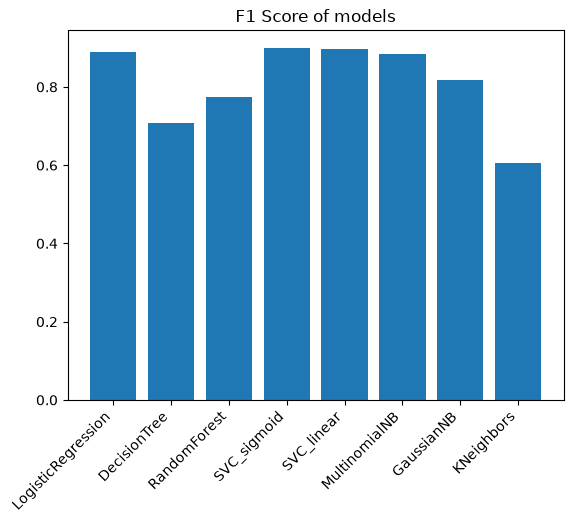

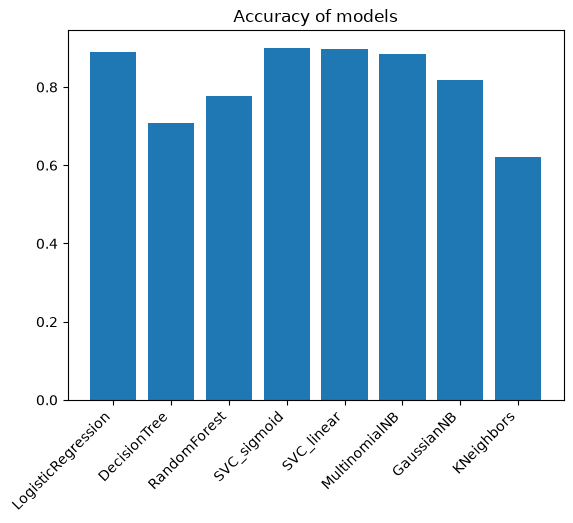

In [128]:
from joblib import Parallel, delayed

# Modelos con hiperparámetros por defecto: es un primer filtro para descartar familias de modelos
models = {
    "LogisticRegression": LogisticRegression(random_state=42),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(random_state=42),
    "SVC_sigmoid": SVC(kernel="sigmoid", random_state=42),
    "SVC_linear": SVC(kernel="linear", random_state=42),
    "MultinomialNB": MultinomialNB(),
    "GaussianNB": GaussianNB(),
    "KNeighbors": KNeighborsClassifier(),
}


def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    """Entrena el modelo con las features de train y devuelve (nombre, (accuracy, F1 ponderado)) en test.
    GaussianNB no acepta matrices dispersas, por eso se le pasa la matriz densa."""
    if isinstance(model, GaussianNB):
        X_train = X_train.toarray()
        X_test = X_test.toarray()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return name, (
        accuracy_score(y_test, y_pred),
        f1_score(y_test, y_pred, average="weighted"),
    )


# Los modelos se entrenan en paralelo. mmap_mode="c" comparte las matrices grandes entre los procesos
# como memoria mapeada (copy-on-write) en lugar de copiarlas en cada uno.
results = Parallel(n_jobs=-1, mmap_mode="c")(
    delayed(evaluate_model)(
        name, model, X_train_transformed, X_test_transformed, y_train, y_test
    )
    for name, model in models.items()
)
model_predictions = dict(results)


plt.bar(
    list(model_predictions.keys()),
    [model_predictions[model_name][1] for model_name in model_predictions],
)
plt.title("F1 Score of models")
plt.xticks(rotation=45, ha="right")
plt.show()

plt.bar(
    list(model_predictions.keys()),
    [model_predictions[model_name][0] for model_name in model_predictions],
)
plt.title("Accuracy of models")
plt.xticks(rotation=45, ha="right")
plt.show()

**Resultados (F1 ponderado aproximado, leído de la gráfica).**

| Modelo | F1 | Comentario |
|---|---|---|
| SVC sigmoide | ≈ 0.90 | Kernel sigmoide; de los mejores |
| SVC lineal | ≈ 0.90 | Modelo lineal de margen máximo |
| Regresión logística | ≈ 0.89 | Lineal, con probabilidades bien calibradas |
| Naive Bayes multinomial | ≈ 0.88 | Modela directamente frecuencias de palabras |
| Naive Bayes gaussiano | ≈ 0.82 | Supone rasgos continuos gaussianos |
| Random forest | ≈ 0.77 | |
| Árbol de decisión | ≈ 0.71 | |
| KNN | ≈ 0.61 | |

**¿Por qué estos resultados?**

- Con ~200 000 rasgos dispersos y 9 600 reseñas, las clases son casi **linealmente separables**. Los modelos lineales regularizados (SVM, regresión logística) aprovechan todos los rasgos a la vez con pocos parámetros efectivos.
- **Naive Bayes multinomial** es el modelo clásico para conteos de palabras. **Naive Bayes gaussiano** supone que cada rasgo es una variable continua con distribución normal, lo que no describe una matriz casi toda de ceros; además necesita la matriz densa.
- Los **árboles** dividen por un rasgo a la vez. En una matriz dispersa cada palabra aparece en pocas reseñas, así que cada división separa muy pocos ejemplos y el árbol sobreajusta. El random forest mejora al promediar árboles, pero sigue por debajo de los lineales.
- **KNN** sufre la maldición de la dimensionalidad: en 200 000 dimensiones dispersas las distancias entre reseñas se parecen mucho y los vecinos más cercanos no son informativos.

**Decisión:** pasamos a la búsqueda de hiperparámetros los cuatro mejores modelos: **regresión logística, SVC lineal, SVC sigmoide y Naive Bayes multinomial**.

## 7. Ajuste de hiperparámetros con `GridSearchCV`

Para cada uno de los cuatro modelos buscamos al mismo tiempo los hiperparámetros del **preprocesamiento** y del **clasificador**:

- **Vectorizador**: `CountVectorizer` (conteos) o `TfidfVectorizer` (TF-IDF), con n-gramas `(1,1)`, `(1,2)` o `(1,3)`. Se reemplaza el paso `vectorizers` completo (el `ColumnTransformer`), así las tres columnas usan siempre la misma configuración y la grilla no crece de forma combinatoria.
- **Clasificador**:
  - `C` (regresión logística y SVM): inverso de la regularización. Probamos 0.1 (regularización fuerte), 1 (el valor por defecto) y 1.1 y 1.2 (algo menos de regularización).
  - `solver` (regresión logística): `lbfgs` y `newton-cg`, dos solvers que soportan la pérdida multinomial.
  - `alpha` (Naive Bayes): el suavizado de las frecuencias, en 0.1, 0.5 y 1.0.

Otras decisiones:

- Para el SVM lineal usamos `LinearSVC` (liblinear) en lugar de `SVC(kernel="linear")` (libsvm): es el mismo tipo de modelo, pero mucho más rápido con matrices dispersas grandes.
- `SVC(kernel="sigmoid", probability=True)`: necesitamos `predict_proba` para el voto suave de la sección 8.
- **Validación cruzada de 5 folds** sobre train, con `scoring="accuracy"` (la métrica de la competencia). El preprocesamiento está dentro del pipeline, así que se reajusta en cada fold y no hay fuga de información.

Para cada modelo mostramos la mejor accuracy de CV por combinación de vectorizador y n-gramas, el reporte de clasificación en test y la matriz de confusión.

Fitting 5 folds for each of 60 candidates, totalling 300 fits


/Users/pedropablosanintrujillo/GitHub/proyecto-ml/.venv/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:787: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


LogisticRegression: TfidfVectorizer ngram=(1, 2) {'clf__C': np.float64(3.0), 'clf__solver': 'lbfgs'}  CV Accuracy=0.8880


ngram_range,"(1, 1)","(1, 2)","(1, 3)"
vectorizer,,,
CountVectorizer,0.8819,0.8824,0.8777
TfidfVectorizer,0.8872,0.8880,0.8841


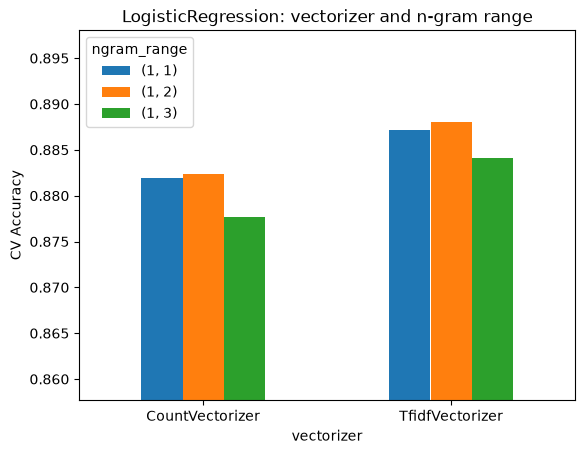

              precision    recall  f1-score   support

    negativo       0.86      0.87      0.86       843
     neutral       0.97      0.99      0.98       715
    positivo       0.87      0.84      0.86       842

    accuracy                           0.90      2400
   macro avg       0.90      0.90      0.90      2400
weighted avg       0.90      0.90      0.90      2400



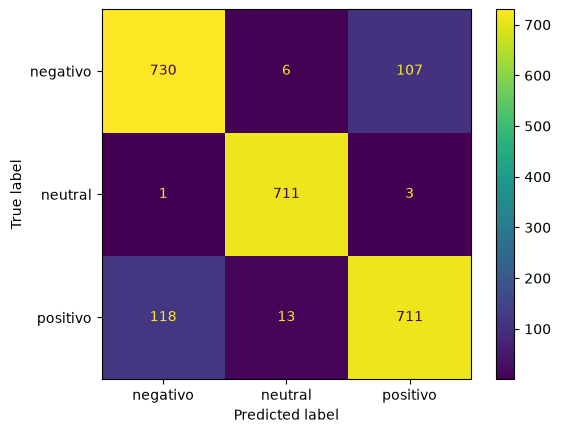

Fitting 5 folds for each of 24 candidates, totalling 120 fits
SVC_linear: CountVectorizer ngram=(1, 1) {'clf__C': 0.1}  CV Accuracy=0.8868


ngram_range,"(1, 1)","(1, 2)","(1, 3)"
vectorizer,,,
CountVectorizer,0.8868,0.8852,0.8808
TfidfVectorizer,0.8841,0.8868,0.8855


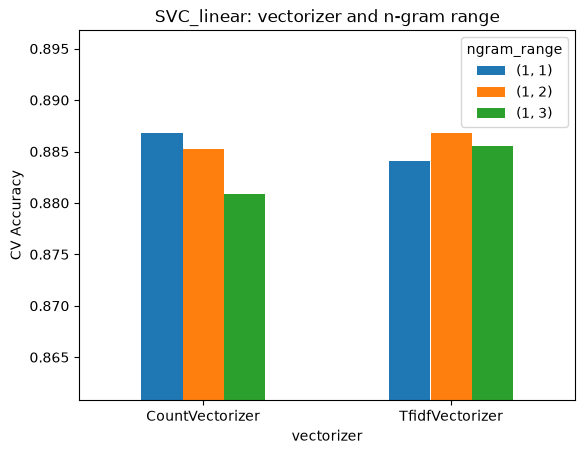

              precision    recall  f1-score   support

    negativo       0.85      0.85      0.85       843
     neutral       0.98      0.99      0.98       715
    positivo       0.85      0.84      0.85       842

    accuracy                           0.89      2400
   macro avg       0.89      0.89      0.89      2400
weighted avg       0.89      0.89      0.89      2400



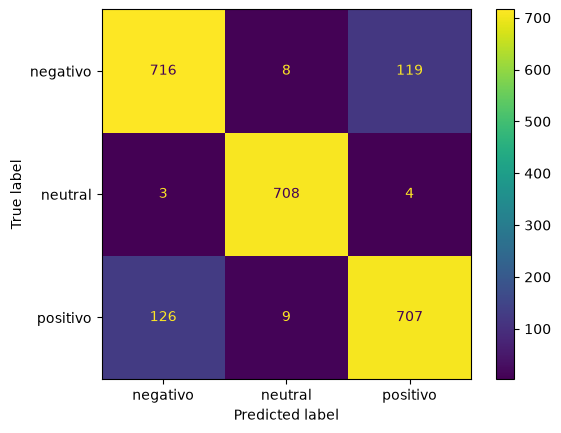

Fitting 5 folds for each of 30 candidates, totalling 150 fits


/Users/pedropablosanintrujillo/GitHub/proyecto-ml/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/pedropablosanintrujillo/GitHub/proyecto-ml/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/pedropablosanintrujillo/GitHub/proyecto-ml/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/pedropablosanintrujillo/GitHub/proyecto-ml

In [ ]:
from itertools import product

VECTORIZER_OPTIONS = ["count", "tfidf"]
NGRAM_OPTIONS = [(1, 1), (1, 2), (1, 3)]

# Cada opción reemplaza el paso "vectorizers" completo, así los tres vectorizadores
# (texto, última oración y contraste) usan siempre el mismo tipo y ngram_range.
vectorizer_options = [
    build_preprocessor(vectorizer, ngram_range).named_steps["vectorizers"]
    for vectorizer, ngram_range in product(VECTORIZER_OPTIONS, NGRAM_OPTIONS)
]


def describe_vectorizer(column_transformer):
    """Devuelve el tipo de vectorizador y su ngram_range a partir del ColumnTransformer."""
    vectorizer = column_transformer.transformers[0][1]
    return type(vectorizer).__name__, str(vectorizer.ngram_range)


# Modelo y grilla de cada candidato. C (regresión logística y SVM) es el inverso de la regularización
# y alpha (Naive Bayes) es el suavizado de Laplace/Lidstone de las frecuencias.
param_grids = {
    "LogisticRegression": (
        LogisticRegression(random_state=42, max_iter=1000),
        {
            "C": np.linspace(1,5 , 5),
            "solver": ["lbfgs", "newton-cg"],
        },
    ),
    # LinearSVC (liblinear) es mucho más rápido que SVC(kernel="linear") con ~200 000 rasgos dispersos
    "SVC_linear": (
        LinearSVC(random_state=42),
        {
            "C": [0.1, 1, 1.1, 1.2],
        },
    ),
    # probability=True: el voto suave del voting classifier necesita predict_proba
    "SVC_sigmoid": (
        SVC(kernel="sigmoid", probability=True, random_state=42),
        {
            "C": np.linspace(2.5,3.5 , 5),
        },
    ),
    "MultinomialNB": (
        MultinomialNB(),
        {
            "alpha": [0.1, 0.5, 1.0],
        },
    ),
}

best_models = {}
for name, (model, grid) in param_grids.items():
    # El preprocesamiento va dentro del pipeline para que el vectorizador se ajuste en cada fold
    pipeline = Pipeline(build_preprocessor().steps + [("clf", model)])
    full_grid = {
        "vectorizers": vectorizer_options,
        **{f"clf__{param}": values for param, values in grid.items()},
    }
    # Validación cruzada de 5 folds sobre train; se optimiza la accuracy, que es la métrica de la competencia
    search = GridSearchCV(
        pipeline, full_grid, cv=5, scoring="accuracy", n_jobs=-1, verbose=1
    )
    search.fit(X_train, y_train)
    best_models[name] = search.best_estimator_

    vectorizer_name, ngram_range = describe_vectorizer(
        search.best_params_["vectorizers"]
    )
    model_params = {k: v for k, v in search.best_params_.items() if k != "vectorizers"}
    print(
        f"{name}: {vectorizer_name} ngram={ngram_range} {model_params}  CV Accuracy={search.best_score_:.4f}"
    )

    # Mejor CV accuracy para cada combinación de vectorizador y n-gramas
    cv_results = pd.DataFrame(search.cv_results_)
    cv_results[["vectorizer", "ngram_range"]] = cv_results["param_vectorizers"].apply(
        lambda ct: pd.Series(describe_vectorizer(ct))
    )
    effect = cv_results.pivot_table(
        index="vectorizer",
        columns="ngram_range",
        values="mean_test_score",
        aggfunc="max",
    )
    display(effect.round(4))
    effect.plot.bar(
        rot=0, ylabel="CV Accuracy", title=f"{name}: vectorizer and n-gram range"
    )
    plt.ylim(effect.min().min() - 0.02, effect.max().max() + 0.01)
    plt.show()

    # El test solo se usa para reportar: la selección de hiperparámetros se hizo con la CV
    y_pred = search.predict(X_test)
    print(classification_report(y_test, y_pred))
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
    plt.show()

**Resultados del grid search.**

| Modelo | Vectorizador | n-gramas | Hiperparámetros | Accuracy (CV) | Accuracy (test) |
|---|---|---|---|---|---|
| Regresión logística | TF-IDF | (1,2) | C=1.2, lbfgs | 0.8869 | 0.89 |
| SVC lineal (`LinearSVC`) | Count | (1,1) | C=0.1 | 0.8868 | 0.89 |
| SVC sigmoide | TF-IDF | (1,1) | C=1.2 | 0.8869 | 0.89 |
| Naive Bayes multinomial | TF-IDF | (1,2) | alpha=0.5 | 0.8803 | 0.88 |

**Observaciones.**

- TF-IDF es igual o mejor que los conteos en los cuatro modelos (en `LinearSVC` empatan: 0.8868). TF-IDF le resta peso a las palabras que aparecen en casi todas las reseñas ("compr", "lleg", "dia"), que no distinguen clases.
- Los trigramas nunca son la mejor opción. En ningún modelo la mejor configuración usa `(1,3)`, y en la mayoría de las combinaciones queda por debajo de `(1,1)` y `(1,2)`, sobre todo en Naive Bayes con conteos (0.848). Agregan miles de rasgos muy específicos que aparecen en pocas reseñas y aumentan la varianza.
- En la regresión logística y el SVC sigmoide, el mejor C es el mayor de la grilla (1.2), así que podría valer la pena ampliarla hacia valores mayores.
- La clase `neutral` está prácticamente resuelta (F1 ≈ 0.98). Casi todos los errores son confusiones entre `positivo` y `negativo`.
- Los cuatro modelos se estancan en ≈ 0.887 de accuracy en CV, aunque son de familias distintas. Eso sugiere que el límite está en la representación y no en el clasificador. Esto motiva dos pasos: combinar los modelos (sección 8) y agregar información nueva sobre la estructura de las opiniones (sección 10).

## 8. Voting classifier con los mejores modelos

Combinamos los cuatro modelos ajustados en un `VotingClassifier`. Cada votante conserva su propio preprocesamiento (vectorizador y n-gramas elegidos en el grid search), así que los modelos ven representaciones algo distintas y cometen errores parcialmente distintos, que el voto puede compensar.

- Voto suave (`voting="soft"`): se promedian las probabilidades de las tres clases en lugar de contar votos. Un modelo muy seguro pesa más que uno indeciso, y con un número par de votantes no hay empates. (Fuera del documento también probamos con `voting="hard"`, pero esto no funcionó tan bien)
- `LinearSVC` no tiene `predict_proba`, así que lo envolvemos en `CalibratedClassifierCV` (calibración sigmoide con 5 folds internos) para convertir sus márgenes en probabilidades comparables con las de los otros modelos.
- Pesos iguales para los cuatro votantes: ajustar los pesos con los mismos datos de validación sobreestimaría el resultado, y los cuatro modelos tienen un desempeño casi idéntico.

In [ ]:
from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import VotingClassifier

# El voto suave promedia las probabilidades de cada modelo (predict_proba). LinearSVC no
# lo implementa, así que lo envolvemos en CalibratedClassifierCV para obtener probabilidades.
# Cada pipeline conserva su propio preprocesamiento (vectorizador y n-gramas del grid search).
# clone crea copias sin entrenar, así el voting no modifica los pipelines de best_models.
voting_estimators = []
for name, pipeline in best_models.items():
    pipeline = clone(pipeline)
    clf = pipeline.named_steps["clf"]
    if not hasattr(clf, "predict_proba"):
        pipeline.set_params(clf=CalibratedClassifierCV(clf, cv=5))
    voting_estimators.append((name, pipeline))

# Todos los votantes pesan lo mismo: ajustar los pesos con los mismos datos sobreestimaría el resultado
voting_clf = VotingClassifier(estimators=voting_estimators, voting="soft", n_jobs=-1)



voting_clf.fit(X_train, y_train)

/Users/pedropablosanintrujillo/GitHub/proyecto-ml/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('LogisticRegression', ...), ('SVC_linear', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionadded:: 0.18",-1
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels.","ndarray[object](3,)","['negativo','neutral','positivo']"
"estimators_ estimators_: list of classifiersThe collection of fitted sub-estimators as defined in ``estimators``that are not 'drop'. Note that sub-estimators are always fitted oninteger-encoded labels (see ``le_`` attribute). When ``y`` containsnon-integer class labels (e.g. strings), use ``le_.inverse_transform``to map predictions back to the original label space.",list,"[Pipeline(step...m_state=42))]), Pipeline(step..._state=42)))]), Pipeline(step...m_state=42))]), Pipeline(step...(alpha=0.5))])]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimators expose such an attribute when fit... versionadded:: 1.0","ndarray[object](2,)","['id','text']"
le_ le_: :class:`~sklearn.preprocessing.LabelEncoder`Transformer used to encode the labels during fit and decode duringprediction. Sub-estimators in ``estimators_`` are fitted on theinteger-encoded labels produced by this encoder.,LabelEncoder,LabelEncoder()


Estimamos el desempeño del voting con validación cruzada estratificada de 5 folds sobre train, para compararlo con la CV de los modelos individuales.

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
# Validación cruzada estratificada de 5 folds sobre train: estima el desempeño del voting sin tocar el test
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(voting_clf, X_train, y_train, cv=cv, scoring="accuracy", n_jobs=-1)

print(f"Accuracy por fold: {cv_scores.round(4)}")
print(f"Accuracy promedio: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

/Users/pedropablosanintrujillo/GitHub/proyecto-ml/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/pedropablosanintrujillo/GitHub/proyecto-ml/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/pedropablosanintrujillo/GitHub/proyecto-ml/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/pedropablosanintrujillo/GitHub/proyecto-ml

Accuracy por fold: [0.8969 0.8792 0.8943 0.901  0.8786]
Accuracy promedio: 0.8900 (+/- 0.0093)


La accuracy promedio en CV es 0.8900 ± 0.0093, frente a 0.8869 del mejor modelo individual. La mejora es pequeña (+0.3 puntos, menor que la desviación entre folds), pero en el test el voting llega a **0.8979** (sección 10), por encima de todos los modelos individuales. Lo usamos como modelo base del stacking final.

## 9. Análisis de errores

Para entender qué limita a los modelos, revisamos las reseñas del test mal clasificadas por el `LinearSVC` ajustado. Los cuatro modelos tienen métricas casi idénticas, así que sus errores son representativos.

In [ ]:
# Reseñas del test mal clasificadas por el LinearSVC ajustado, uno de los mejores modelos individuales
y_pred_linear_svc = best_models["SVC_linear"].predict(X_test)



mal_clasificados = pd.DataFrame(columns=["text", "label"])
errores = y_pred_linear_svc != y_test
mal_clasificados["text"] = X_test.loc[errores, TEXT_COLUMN]
mal_clasificados["label"] = y_test[errores]
mal_clasificados["predicted_label"] = y_pred_linear_svc[errores]

mal_clasificados

,text,label,predicted_label
3225,Lo pedí por la página web y me llegó en seis d...,neutral,positivo
990,Lo compré para reemplazar otro que ya tenía en...,negativo,positivo
8896,Lo pedí a mediados de mes y me llegó en unos c...,negativo,positivo
5050,Hace como una semana se lo compré a un familia...,negativo,positivo
1849,Lo compré hace unos meses para el escritorio d...,positivo,negativo
...,...,...,...
7773,Lo compré hace unos días por internet y llegó ...,positivo,negativo
4706,Lo compré a inicios de año y llegó en tres día...,positivo,negativo
5806,"Lo compré hace un mes para la oficina, llegó e...",positivo,negativo
1614,Me llegó el procesador el jueves por la mañana...,positivo,negativo


**Observaciones.** El `LinearSVC` comete 269 errores en las 2 400 reseñas del test. Como la clase `neutral` tiene precisión 0.98 y recall 0.99, casi todos son confusiones entre `positivo` y `negativo`. Al leer estas reseñas vemos que tienen **opiniones positivas y negativas a la vez**, como "La pantalla me decepcionó. [...] Al final, el empaque quedó correcto": es justamente la dificultad que describe el enunciado.

Las columnas de última oración y de contraste ayudan, pero solo miran una oración y el último conector de una lista fija. No distinguen, por ejemplo, entre una opinión final que cierra la reseña ("al final, ...") y un comentario al margen ("por cierto, ..."). Analizaremos la estructura de estas reseñas para identificar patrones que mejoren nuestros modelos.

## 10. Segundo modelo: opiniones etiquetadas y stacking

El voting classifier ya separa casi perfectamente la clase `neutral`. Sus errores son reseñas positivas y negativas con opiniones opuestas, por ejemplo "La pantalla me decepcionó.",  "Al final, el empaque quedó correcto". En ellas la etiqueta la decide la última opinión, sobre todo cuando va después de un conector conclusivo ("al final", "aun así", "con todo", "a fin de cuentas", "sin embargo", "pero"). En cambio, cuando va después de un comentario al margen ("de paso", "por cierto", "por otro lado", "además"), la última opinión casi no decide nada. Lo comprobamos con los datos de train en la sección 10.1.

**Preprocesamiento del modelo de opiniones.** Una bolsa de palabras sobre todo el texto mezcla ambas opiniones con las oraciones de relleno (compra, envío, uso), así que no sabe cuál pesa más. Por eso entrenamos un segundo modelo con otro preprocesamiento:

1. `segmentar` divide la reseña en cláusulas (por puntuación y por conectores como "pero", "aunque" o "y") y guarda el conector que introduce cada una.
2. `polaridad_por_reglas` asigna a cada cláusula una polaridad (+1, −1 o 0) con listas de frases fijas ("me arrepiento", "cinco estrellas") y de adjetivos de opinión. La polaridad de los adjetivos se invierte después de un negador ("nada flojo" es positivo). Las reseñas parecen generadas con plantillas que repiten un vocabulario de opinión limitado, y las listas recogen ese vocabulario. Las reglas no usan etiquetas, así que no filtran información. (Cabe recalcar que usamos Claude para identificar estas listas de frases, palabras y oraciones)
3. `etiquetar_opinion` conserva solo las cláusulas con opinión (o las que siguen a un conector conclusivo) y marca cada palabra con:
   - su posición: `ULT_` si pertenece a la última opinión y `PREV_` si pertenece a una anterior;
   - el tipo de conector que la introduce: `CONC` (conclusivo), `DEB` (comentario al margen), `OTRO` o `NADA`;
   - además, un token `POL_...` por opinión con su polaridad según las reglas.

Así un modelo lineal puede aprender, por ejemplo, que `CONC_ULT_correcto` indica una reseña positiva aunque haya una queja antes. Cada palabra aparece en dos versiones, `ULT_x` y `CONC_ULT_x`: la primera generaliza entre conectores y la segunda se especializa por conector. Es una interacción posición × conector hecha a mano, que un modelo lineal no podría aprender por sí solo. Las reseñas sin opiniones quedan como `VACIO`, lo que también ayuda a reconocer las neutrales.

Los dos modelos se combinan con un stacking, una regresión logística final recibe las probabilidades del voting classifier y del modelo de opiniones, y aprende cuándo confiar en cada uno.

In [ ]:
# Preprocesamiento del modelo de opiniones: cada reseña se reduce a sus opiniones y cada
# palabra se marca con su posición (última opinión o anterior) y el tipo de conector que la introduce.

# Frases y adjetivos de opinión del generador de reseñas (sin tildes, como el texto normalizado)
FRASES_NEGATIVAS = [
    "no vale lo que cuesta",
    "me decepciono",
    "por debajo de la media",
    "se queda muy corto",
    "se queda corto",
    "se dano antes",
    "no es para nada lo que esperaba",
    "defraudo todas mis expectativas",
    "tire el dinero",
    "funciona bastante mal",
    "dolor de cabeza",
    "me arrepiento",
    "no le recomiendo",
    "error de compra",
    "quede muy molesto",
    "no volveria a comprar",
    "una estrella",
    "no pare de tener problemas",
    "arrepentido",
    "termine harto",
]
FRASES_POSITIVAS = [
    "justo lo que estaba buscando",
    "vale totalmente la pena",
    "fue todo un acierto",
    "me encanto",
    "funciona de maravilla",
    "respondio tal como esperaba",
    "supero todas mis expectativas",
    "cumple de sobra",
    "por encima de la media",
    "me alegra haber elegido",
    "me sorprendio para bien",
    "me hizo la vida mas facil",
    "termine feliz",
    "estoy feliz",
    "quede encantado",
    "con los ojos cerrados",
    "volveria a comprar",
    "ni una sola queja",
    "cinco estrellas",
]
ADJETIVOS_POSITIVOS = [
    "funcional",
    "resistente",
    "impecable",
    "sobresaliente",
    "veloz",
    "confiable",
    "excelente",
    "eficiente",
    "formidable",
    "fiable",
    "potente",
    "superior",
    "decente",
    "notable",
    "espectacular",
    "durable",
    "practica",
    "practico",
    "cumplidor",
    "cumplidora",
    "agradable",
    "comodisima",
    "comodisimo",
    "buenisima",
    "buenisimo",
    "rapidisima",
    "rapidisimo",
    "comoda",
    "comodo",
    "optimo",
    "optima",
    "correcta",
    "correcto",
    "solida",
    "solido",
    "redonda",
    "redondo",
    "ligera",
    "ligero",
    "completa",
    "completo",
    "robusta",
    "robusto",
    "buena",
    "bueno",
    "nitida",
    "nitido",
    "precisa",
    "preciso",
    "estupenda",
    "estupendo",
    "bien hecha",
    "bien hecho",
    "bien logrado",
    "bien lograda",
    "bien construida",
    "bien construido",
]
ADJETIVOS_NEGATIVOS = [
    "torpe",
    "pobre",
    "terrible",
    "decepcionante",
    "endeble",
    "debil",
    "desagradable",
    "fragil",
    "corriente",
    "inestable",
    "deficiente",
    "mediocre",
    "inconsistente",
    "olvidable",
    "incumplidor",
    "incumplidora",
    "ruidosa",
    "ruidoso",
    "imprecisa",
    "impreciso",
    "delicada",
    "delicado",
    "lentisima",
    "lentisimo",
    "pesima",
    "pesimo",
    "malisima",
    "malisimo",
    "flojo",
    "floja",
    "ordinaria",
    "ordinario",
    "aparatoso",
    "aparatosa",
    "chapucera",
    "chapucero",
    "basica",
    "basico",
    "incomoda",
    "incomodo",
    "limitado",
    "limitada",
    "defectuosa",
    "defectuoso",
    "mal terminada",
    "mal terminado",
    "mal construida",
    "mal construido",
    "mal hecha",
    "mal hecho",
]
ADJ_POS_SIMPLES = {a for a in ADJETIVOS_POSITIVOS if " " not in a}
ADJ_NEG_SIMPLES = {a for a in ADJETIVOS_NEGATIVOS if " " not in a}
ADJ_POS_COMPUESTOS = [a for a in ADJETIVOS_POSITIVOS if " " in a]
ADJ_NEG_COMPUESTOS = [a for a in ADJETIVOS_NEGATIVOS if " " in a]

# Conectores que pueden introducir una cláusula. Se ordenan de más largo a más corto para que, si en el
# contexto aparecen varios, gane el más específico ("a fin de cuentas", "sin embargo") sobre "y" o "pero".
CONECTORES = sorted(
    [
        "sin embargo",
        "eso si",
        "aun asi",
        "lo que si",
        "no obstante",
        "a fin de cuentas",
        "al final",
        "con todo",
        "por otro lado",
        "por cierto",
        "de paso",
        "ademas",
        "ahora",
        "pero",
        "aunque",
        "y",
        "la verdad",
    ],
    key=len,
    reverse=True,
)
# Una cláusula termina en un signo de puntuación o antes de un conector de contraste o de "y". El grupo
# de captura hace que re.split también devuelva el separador, para saber qué conector introduce la cláusula siguiente.
SEPARADOR_CLAUSULAS = re.compile(
    r"([.;!?]|,?\s\b(?:pero|aunque|sin embargo|eso si|aun asi|lo que si|no obstante|y)\b)"
)
# Conectores conclusivos o de contraste: la opinión que sigue suele decidir la reseña.
# En train, la polaridad de la última opinión coincide con la etiqueta en el 93-100 % de los casos tras
# estos conectores (ver la tabla de la sección 10.1).
CONECTORES_CONCLUSIVOS = {
    "a fin de cuentas",
    "al final",
    "aun asi",
    "con todo",
    "sin embargo",
    "pero",
}
# Conectores que agregan un comentario al margen ("de paso, ...", "por cierto, ..."): tras ellos la
# última opinión coincide con la etiqueta solo en el 53-63 % de los casos, casi al azar.
CONECTORES_DEBILES = {"de paso", "por cierto", "por otro lado", "ademas"}

def polaridad_por_reglas(clausula):
    """+1, -1 o 0 según las frases fijas y, si no hay, los adjetivos (invertidos dentro de una negación)."""
    # Las frases fijas deciden primero: contienen palabras que confundirían a los adjetivos ("no vale lo que cuesta")
    if any(f in clausula for f in FRASES_NEGATIVAS):
        return -1
    if any(f in clausula for f in FRASES_POSITIVAS):
        return 1
    # Después, los adjetivos compuestos ("bien hecho", "mal terminado")...
    puntaje = sum(a in clausula for a in ADJ_POS_COMPUESTOS) - sum(
        a in clausula for a in ADJ_NEG_COMPUESTOS
    )
    # ...y los simples, cuya polaridad se invierte después de un negador ("nada flojo" es positivo)
    negando = False
    for palabra in re.findall(r"[a-z]+", clausula):
        if palabra in NEGADORES:
            negando = True
            continue
        polaridad = (palabra in ADJ_POS_SIMPLES) - (palabra in ADJ_NEG_SIMPLES)
        puntaje += -polaridad if negando else polaridad
    return int(np.sign(puntaje))


def segmentar(texto):
    """Lista de (cláusula, conector que la introduce, polaridad por reglas)."""
    # partes alterna [cláusula, separador, cláusula, separador, ...]
    partes = SEPARADOR_CLAUSULAS.split(quitar_tildes(texto.lower()))
    clausulas, separador = [], ""
    for i in range(0, len(partes), 2):
        clausula = partes[i].strip(" ,")
        if clausula:
            # El conector puede ser el separador (", pero ...") o estar al inicio de la cláusula
            # ("Al final, ..."), por eso se busca en el separador y en los primeros 30 caracteres.
            contexto = separador + " " + clausula[:30]
            conector = next(
                (c for c in CONECTORES if re.search(rf"\b{c}\b", contexto)), ""
            )
            clausulas.append((clausula, conector, polaridad_por_reglas(clausula)))
        separador = partes[i + 1] if i + 1 < len(partes) else ""
    return clausulas


def grupo_conector(conector):
    """Tipo de conector: conclusivo, comentario al margen, otro o ninguno."""
    if conector in CONECTORES_CONCLUSIVOS:
        return "CONC"
    if conector in CONECTORES_DEBILES:
        return "DEB"
    return "OTRO" if conector else "NADA"


def etiquetar_opinion(texto):
    """Deja solo las cláusulas con opinión (o que siguen a un conector conclusivo) y marca cada palabra
    con su posición (ULT: última opinión, PREV: anterior) y el tipo de conector que la introduce.
    También agrega un token con la polaridad por reglas de cada opinión."""
    # Se conservan las cláusulas con polaridad y las que siguen a un conector conclusivo, aunque las
    # listas no detecten su polaridad. Las cláusulas de relleno (compra, envío, uso) se descartan.
    opiniones = [
        (clausula, conector, polaridad)
        for clausula, conector, polaridad in segmentar(texto)
        if polaridad or conector in CONECTORES_CONCLUSIVOS
    ]
    tokens = []
    for i, (clausula, conector, polaridad) in enumerate(opiniones):
        posicion = "ULT" if i == len(opiniones) - 1 else "PREV"
        grupo = grupo_conector(conector)
        palabras = re.findall(r"[a-z]+", clausula)
        # Dos versiones de cada palabra: ULT_x generaliza entre conectores y CONC_ULT_x se especializa por
        # conector. Es una interacción posición x conector construida a mano, porque un modelo lineal no
        # puede aprenderla por sí solo.
        tokens += [f"{posicion}_{palabra}" for palabra in palabras]
        tokens += [f"{grupo}_{posicion}_{palabra}" for palabra in palabras]
        tokens.append(f"POL_{posicion}_{grupo}_{polaridad}")
    # Las reseñas sin opiniones (casi siempre neutrales) se representan con un token propio
    return " ".join(tokens) or "VACIO"


def etiquetar_opiniones(X):
    """Aplica etiquetar_opinion a la columna de texto (se usa dentro de un FunctionTransformer)."""
    return X[TEXT_COLUMN].apply(etiquetar_opinion)


ejemplo = "Me decepcionó la pantalla. Lo uso a diario. Al final, el empaque quedó correcto."
print(etiquetar_opinion(ejemplo))

PREV_me PREV_decepciono PREV_la PREV_pantalla NADA_PREV_me NADA_PREV_decepciono NADA_PREV_la NADA_PREV_pantalla POL_PREV_NADA_-1 ULT_al ULT_final ULT_el ULT_empaque ULT_quedo ULT_correcto CONC_ULT_al CONC_ULT_final CONC_ULT_el CONC_ULT_empaque CONC_ULT_quedo CONC_ULT_correcto POL_ULT_CONC_1


En el ejemplo, "Lo uso a diario" se descarta porque no tiene opinión ni sigue a un conector conclusivo. La queja inicial queda como `PREV_...`, sin conector (`NADA`) y con polaridad `POL_PREV_NADA_-1`. La opinión final queda como `ULT_...` / `CONC_ULT_...` con `POL_ULT_CONC_1`. El modelo puede aprender que esta última combinación indica `positivo` aunque haya una queja antes.

### 10.1 Evidencia: la última opinión y su conector

Con las funciones anteriores medimos, solo con train, con qué frecuencia la polaridad de la última opinión de una reseña coincide con su etiqueta, según el conector que la introduce. Las reseñas neutrales en las que se detecta alguna opinión cuentan como desacierto. Esta tabla es la que justifica los grupos `CONC` y `DEB` de `grupo_conector`.

In [ ]:
# ¿Con qué frecuencia la polaridad de la última opinión coincide con la etiqueta, según el conector que la
# introduce? Se calcula solo con train, para no usar el test al decidir los grupos de conectores.
POLARIDAD_A_ETIQUETA = {1: "positivo", -1: "negativo"}


def ultima_opinion(texto):
    """(cláusula, conector, polaridad) de la última cláusula con polaridad, o None si no hay ninguna."""
    opiniones = [opinion for opinion in segmentar(texto) if opinion[2] != 0]
    return opiniones[-1] if opiniones else None


ultimas = X_train[TEXT_COLUMN].apply(ultima_opinion)
con_opinion = ultimas.notna()
analisis_conectores = pd.DataFrame(
    {
        "conector": ultimas[con_opinion].apply(lambda o: o[1]),
        # Las reseñas neutrales con alguna opinión detectada cuentan como desacierto
        "coincide": ultimas[con_opinion].apply(lambda o: POLARIDAD_A_ETIQUETA[o[2]])
        == y_train[con_opinion],
    }
)
analisis_conectores["grupo"] = analisis_conectores["conector"].apply(grupo_conector)
tabla_conectores = (
    analisis_conectores.assign(conector=analisis_conectores["conector"].replace("", "(ninguno)"))
    .groupby("conector")
    .agg(
        resenas=("coincide", "size"),
        coincidencia=("coincide", "mean"),
        grupo=("grupo", "first"),
    )
    .sort_values("coincidencia", ascending=False)
)
display(tabla_conectores.round(3))

# Si se usara como regla: ¿a cuántas reseñas aplica y cuánto acierta?
tras_conclusivo = analisis_conectores["grupo"] == "CONC"
print(
    f"Reseñas de train cuya última opinión sigue a un conector conclusivo: "
    f"{tras_conclusivo.sum()} ({tras_conclusivo.sum() / len(X_train):.1%})"
)
print(
    f"En ellas, la polaridad de esa opinión coincide con la etiqueta en el "
    f"{analisis_conectores.loc[tras_conclusivo, 'coincide'].mean():.1%}"
)

,resenas,coincidencia,grupo
conector,,,
a fin de cuentas,183,1.000,CONC
sin embargo,93,0.989,CONC
aun asi,523,0.989,CONC
al final,652,0.988,CONC
con todo,299,0.983,CONC
pero,251,0.928,CONC
la verdad,321,0.925,OTRO
aunque,42,0.905,OTRO
lo que si,65,0.892,OTRO


Reseñas de train cuya última opinión sigue a un conector conclusivo: 2001 (20.8%)
En ellas, la polaridad de esa opinión coincide con la etiqueta en el 98.1%


**Observaciones.**

- Conectores conclusivos (`CONC`): después de "a fin de cuentas", "sin embargo", "aun así", "al final" y "con todo", la última opinión coincide con la etiqueta en el 98–100 % de los casos; después de "pero", en el 92.8 %.
- Comentarios al margen (`DEB`): después de "además", "por cierto", "de paso" y "por otro lado", la coincidencia baja al 53–63 %, poco más que el azar entre dos clases. Ahí la última opinión no es la que decide.
- Sin conector (`NADA`, 2 263 reseñas), la última opinión acierta el 72.7 %: ayuda, pero no basta.
- "la verdad" (0.925) tiene una coincidencia parecida a la de "pero" y quedó en `OTRO`. Moverla a `CONC` es una mejora posible que no probamos.


### 10.2 Entrenamiento del stacking

- **Modelo de opiniones**: `FunctionTransformer(etiquetar_opiniones)` → `TfidfVectorizer` → `LogisticRegression`.
  - `token_pattern=r"\S+"`. Los tokens ya vienen separados por espacios. El patrón por defecto de scikit-learn descartaría el signo y el dígito de `POL_ULT_CONC_-1`, y no distinguiría la polaridad −1 de la +1.
  - `sublinear_tf=True` usa 1 + log(tf), para que una palabra repetida no domine la reseña.
  - `max_iter=3000` para asegurar que el solver converja.
- **Meta-modelo** (`final_estimator`): una regresión logística sobre 6 rasgos (las probabilidades de las 3 clases de cada modelo). Con tan pocos rasgos, un modelo lineal basta y casi no puede sobreajustar.
- **Probabilidades fuera de fold** (`cv=StratifiedKFold(5)`): las probabilidades con las que se entrena el meta-modelo vienen de modelos que no vieron esa reseña. Si se usaran las de train, el meta-modelo confiaría de más en el modelo que más sobreajusta.
- **Backend de hilos**: el stacking se entrena con `joblib.parallel_config(backend="threading")`. Con procesos, joblib devuelve copias de las funciones definidas en el notebook (`add_last_sentences`, `etiquetar_opiniones`...) que después `joblib.dump` no puede guardar.

**Cierre ambiguo (solo para el análisis).** Algunas reseñas terminan con un cierre que no toma partido ("Todavía no me decido", "Hay de todo, como se ve"...). `PATRON_CIERRE_AMBIGUO` las detecta **solo para separar los resultados por grupo**; no es un rasgo del modelo. Comparamos los tres modelos en el test: el voting y el modelo de opiniones (ajustados dentro del stacking con todo `X_train`) y el stacking completo.

/Users/pedropablosanintrujillo/GitHub/proyecto-ml/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/pedropablosanintrujillo/GitHub/proyecto-ml/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/pedropablosanintrujillo/GitHub/proyecto-ml/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/pedropablosanintrujillo/GitHub/proyecto-ml

,accuracy,sin cierre ambiguo (2074),con cierre ambiguo (326)
Voting classifier,0.8979,0.9508,0.5613
Modelo de opiniones,0.8892,0.9503,0.5000
Stacking (modelo final),0.9038,0.9653,0.5123


              precision    recall  f1-score   support

    negativo       0.86      0.87      0.87       843
     neutral       1.00      1.00      1.00       715
    positivo       0.87      0.86      0.86       842

    accuracy                           0.90      2400
   macro avg       0.91      0.91      0.91      2400
weighted avg       0.90      0.90      0.90      2400



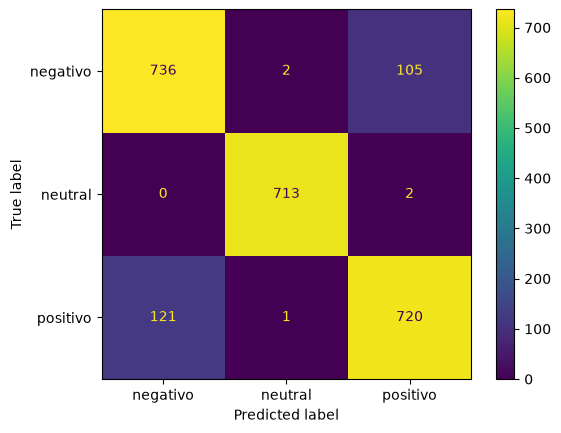

In [ ]:
import joblib
from sklearn.ensemble import StackingClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import RidgeClassifier

# Modelo de opiniones: su propio preprocesamiento (opiniones etiquetadas) + TF-IDF + regresión logística
modelo_opiniones = Pipeline(
    [
        ("opiniones", FunctionTransformer(etiquetar_opiniones)),
        # token_pattern=r"\S+": los tokens ya vienen separados por espacios. El patrón por defecto (\w\w+)
        # descartaría el "-" y el dígito de POL_ULT_CONC_-1, y no distinguiría la polaridad -1 de la +1.
        # sublinear_tf=True usa 1 + log(tf) para que una palabra repetida no domine la reseña.
        ("tfidf", TfidfVectorizer(token_pattern=r"\S+", sublinear_tf=True)),
        ("clf", LogisticRegression(max_iter=3000)),
    ]
)

# Stacking: la regresión logística final combina las probabilidades de ambos modelos,
# calculadas por validación cruzada (cv) para que no estén sobreajustadas. Recibe solo 6 rasgos
# (3 probabilidades x 2 modelos), así que un modelo lineal simple basta y casi no puede sobreajustar.
modelo_final = StackingClassifier(
    estimators=[("votacion", voting_clf), ("opiniones", modelo_opiniones)],
    final_estimator=RidgeClassifier(max_iter=1000),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    stack_method="predict_proba",
    n_jobs=-1,
)
# Se entrena con hilos (threading): los procesos paralelos devuelven copias de las funciones
# definidas en el notebook (add_last_sentences, etiquetar_opiniones...) y joblib.dump no podría
# guardar el modelo
with joblib.parallel_config(backend="threading"):
    modelo_final.fit(X_train, y_train)

# Cierres que no toman partido ("Todavía no me decido"...): solo para separar los resultados,
# porque en esas reseñas la etiqueta es prácticamente aleatoria
PATRON_CIERRE_AMBIGUO = re.compile(
    r"cada quien|no me decido|sigo con (?:la )?dudas?|ni tan bueno ni tan malo|"
    r"ni lo mejor ni lo peor|para gustos|ni fu ni fa|no sabria bien|hay de todo|"
    r"a criterio|ahi lo dejo|sopesalo|lo dejo a tu|sentimientos encontrados|"
    r"sin decidirme|tan buena o tan mala|no se si|todavia no se|"
    r"sacara sus conclusiones|o lo devuelvo|sigo pensandolo"
)
cierre_ambiguo = (
    X_test[TEXT_COLUMN]
    .apply(lambda t: bool(PATRON_CIERRE_AMBIGUO.search(quitar_tildes(t.lower()))))
    .to_numpy()
)

# Los estimadores base dentro del stacking quedan ajustados con todo X_train. El stacking les
# entrega las etiquetas codificadas como enteros, así que se traducen con modelo_final.classes_
clases = modelo_final.classes_
predicciones = {
    "Voting classifier": clases[modelo_final.named_estimators_["votacion"].predict(X_test)],
    "Modelo de opiniones": clases[modelo_final.named_estimators_["opiniones"].predict(X_test)],
    "Stacking (modelo final)": modelo_final.predict(X_test),
}
comparacion = {}
for nombre, prediccion in predicciones.items():
    aciertos = prediccion == y_test.to_numpy()
    comparacion[nombre] = {
        "accuracy": aciertos.mean(),
        f"sin cierre ambiguo ({(~cierre_ambiguo).sum()})": aciertos[~cierre_ambiguo].mean(),
        f"con cierre ambiguo ({cierre_ambiguo.sum()})": aciertos[cierre_ambiguo].mean(),
    }
display(pd.DataFrame(comparacion).T.round(4))

print(classification_report(y_test, predicciones["Stacking (modelo final)"]))
ConfusionMatrixDisplay.from_predictions(y_test, predicciones["Stacking (modelo final)"])
plt.show()

## 11. Resultados del modelo final

El modelo final es un único `StackingClassifier` de scikit-learn, armado solo con pipelines y modelos clásicos:

1. **Voting classifier** (`votacion`): el voto suave de los cuatro mejores modelos del grid search (regresión logística, `LinearSVC` calibrado, SVC sigmoide y Naive Bayes multinomial). Cada uno tiene su propio preprocesamiento: texto sin la primera oración, última oración y oración tras el último conector de contraste, con TF-IDF o conteos, tokenización, stemming y marcado de negación.
2. **Modelo de opiniones** (`opiniones`): un pipeline con otro preprocesamiento.
   - `FunctionTransformer(etiquetar_opiniones)` reduce cada reseña a sus opiniones etiquetadas por posición y conector.
   - `TfidfVectorizer` las vectoriza.
   - Una `LogisticRegression` las clasifica.
3. **Regresión logística final** (`final_estimator`): recibe las probabilidades de las tres clases de ambos modelos (6 rasgos) y aprende cómo combinarlas. En la práctica:
   - confía en el voting classifier para separar la clase `neutral`;
   - combina ambos modelos para decidir entre `positivo` y `negativo`.

Para que la regresión logística final no aprenda de probabilidades sobreajustadas, el stacking las calcula por **validación cruzada de 5 folds**: las probabilidades de cada reseña de entrenamiento vienen de modelos que no la vieron. Después, los dos modelos base se reentrenan con todo el conjunto de entrenamiento.

**Resultados en la partición train/test** (ver la tabla de la celda anterior):

| Modelo | Accuracy | Sin cierre ambiguo (2 074) | Con cierre ambiguo (326) |
|---|---|---|---|
| Voting classifier | 0.8979 | 0.9508 | 0.5613 |
| Modelo de opiniones | 0.8892 | 0.9503 | 0.5000 |
| **Stacking** | **0.9038** | **0.9653** | 0.5123 |

- El stacking supera a los dos modelos base. Cada uno por separado tiene una accuracy parecida, pero sus errores son distintos y el meta-modelo los complementa.
- La mejora está en las reseñas **sin cierre ambiguo**, donde el stacking pasa de 0.9508 (voting) a 0.9653.
- El 13.6 % de las reseñas del test (326) termina con un cierre que no toma partido. En ellas la etiqueta es prácticamente aleatoria y ningún modelo supera mucho el 50 %, así que las diferencias en esa columna son azar.
- Esto da un **techo aproximado** para el problema: aun acertando todas las reseñas sin cierre ambiguo y la mitad de las ambiguas, la accuracy sería ≈ 0.86 + 0.07 ≈ 0.93.
- En la matriz de confusión, la clase `neutral` queda perfecta (precisión y recall 1.00) y los errores se reparten de forma simétrica entre `positivo` y `negativo` (F1 de 0.87 y 0.86), así que el modelo no favorece a ninguna de las dos.

## 12. Archivo de submission

`create_submission_file` lee un archivo de evaluación, predice cada reseña y guarda el CSV con el formato `id,answer` que pide la competencia. Como el stacking incluye todo su preprocesamiento, se le pasa `transform=lambda df: df` y el modelo recibe directamente el DataFrame de `eval.csv`.

En la celda siguiente, el stacking se reentrena con `X_train` (las 9 600 reseñas de entrenamiento) y se predicen las 3 000 reseñas de `data/eval.csv`, que se guardan en `submission_10.csv`. Al final se muestra la distribución de las clases predichas, para comprobar que es parecida a la de train.

> **Nota.** Para guardar el modelo entrenado (por ejemplo, con `joblib.dump(modelo_final, "model/modelo_final.joblib")`), hay que entrenarlo y guardarlo dentro de `with joblib.parallel_config(backend="threading"):`, por la razón explicada en la sección 10.2. Para cargarlo con `joblib.load` hay que ejecutar antes las celdas donde se definen las funciones que usa el pipeline: preprocesamiento (`tokenizer_stemmer`, `build_preprocessor`...) y opiniones (`etiquetar_opiniones`...).

In [ ]:
def create_submission_file(
    eval_file, model, transform=preprocessor.transform, filename="submission_8.csv"
):
    """Predice eval_file con el modelo y guarda la submission. transform convierte las reseñas en las
    features con las que se entrenó el modelo (por defecto, el preprocesador TF-IDF). Para un modelo que ya
    incluye su preprocesamiento, como el stacking, se pasa transform=lambda df: df."""
    eval_file = pd.read_csv(eval_file)
    submission = pd.DataFrame(
        {"id": eval_file["id"], "answer": model.predict(transform(eval_file))}
    )
    submission.to_csv(filename, index=False)

In [ ]:
# Modelo de la entrega: se reentrena el stacking con X_train (9 600 reseñas) y se predice eval.csv.
# eval.csv tiene las mismas columnas que X (id, text) y el modelo incluye su preprocesamiento,
# por eso transform es la identidad.

modelo_final.fit(X_train, y_train)
create_submission_file(
    "data/eval.csv", modelo_final, transform=lambda df: df, filename="submission_10.csv"
)
print(pd.read_csv("submission_10.csv")["answer"].value_counts())

/Users/pedropablosanintrujillo/GitHub/proyecto-ml/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/pedropablosanintrujillo/GitHub/proyecto-ml/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/pedropablosanintrujillo/GitHub/proyecto-ml/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/pedropablosanintrujillo/GitHub/proyecto-ml

answer
positivo    1092
negativo    1081
neutral      827
Name: count, dtype: int64


Arquitectura completa del modelo final:

In [ ]:
modelo_final

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.The type of estimator is generally expected to be a classifier.However, one can pass a regressor for some use case (e.g. ordinalregression).","[('votacion', ...), ('opiniones', ...)]"
,"final_estimator final_estimator: estimator, default=NoneA classifier which will be used to combine the base estimators.The default classifier is a:class:`~sklearn.linear_model.LogisticRegression`.",LogisticRegre...max_iter=1000)
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",StratifiedKFo... shuffle=True)
,"stack_method stack_method: {'auto', 'predict_proba', 'decision_function', 'predict'}, default='auto'Methods called for each base estimator. It can be:* if 'auto', it will try to invoke, for each estimator, `'predict_proba'`, `'decision_function'` or `'predict'` in that order.* otherwise, one of `'predict_proba'`, `'decision_function'` or `'predict'`. If the method is not implemented by the estimator, it will raise an error.",'predict_proba'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary <n_jobs>` for more details.",-1
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,) or list of ndarray if `y` is of type `""multilabel-indicator""`.Class labels.","ndarray[object](3,)","['negativo','neutral','positivo']"
"estimators_ estimators_: list of estimatorsThe elements of the `estimators` parameter, having been fitted on thetraining data. If an estimator has been set to `'drop'`, itwill not appear in `estimators_`. When `cv=""prefit""`, `estimators_`is set to `estimators` and is not fitted again.",list,"[VotingClassif...voting='soft'), Pipeline(step..._iter=3000))])]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimators expose s

## 13. Conclusiones y limitaciones

**Qué funcionó.**

1. **Codificar la posición en la bolsa de palabras.** Separar la última oración y la oración tras el contraste en columnas propias fue el cambio más grande: la regresión logística pasó de 0.725 a ≈ 0.885 en CV (sección 5.1). Quitar la primera oración no tuvo un efecto medible.
2. **Preprocesamiento adaptado al español y al sentimiento**: quitar tildes, conservar negadores e intensificadores, marcar el alcance de la negación y aplicar stemming.
3. **Modelos lineales regularizados.** En texto disperso de alta dimensión superan claramente a árboles, KNN y Naive Bayes gaussiano.
4. **Combinar modelos con información distinta.** El voting aporta poco porque sus votantes usan representaciones parecidas. El stacking con un modelo que ve otra representación (opiniones × posición × conector) sí mejora: de 0.8979 a 0.9038 en test, y de 0.951 a 0.965 en las reseñas sin cierre ambiguo.

**Limitaciones.**

- Las listas de frases, adjetivos y conectores están hechas a mano a partir del vocabulario de estas reseñas. (En este caso Claude ayudó a sacar el vocabulario)
- Una bolsa de palabras, aun con prefijos de posición, solo captura las interacciones que se le construyen a mano. Como dice el enunciado, un modelo secuencial podría aprender el efecto del orden, la negación y los conectores directamente (Parte 2).
- Cerca del 13 % de las reseñas tiene un cierre ambiguo, con una etiqueta prácticamente aleatoria. Eso pone un techo de ≈ 0.93 a cualquier modelo.